# 📘 Notebook: CQED Molecular Dynamics with Frozen Atoms

🧠 Overview

In this notebook, we run velocity Verlet molecular dynamics using the CQED calculator.

We also show how to freeze one or more atoms during the trajectory by:

- zeroing the corresponding force components
- zeroing their velocities
- preventing their coordinates from updating

This is useful for anchoring part of a molecule while letting the other atoms evolve naturally.

In [6]:
import numpy as np
import psi4
import matplotlib.pyplot as plt

psi4.core.be_quiet()

from cqed_rhf import CQEDRHFCalculator
from cqed_rhf.utils import write_xyz, ANGSTROM_TO_BOHR
from cqed_rhf.drivers import velocity_verlet_md

# 🧬 Example Geometry

Here we use a small example geometry of water with oxygen frozen. You can replace this with the nitrobenzene with Br+ anchored.

After defining the geometry, we will set some psi4 options, define the cavity vector, and instatiate the CQED calculator.

In [7]:
geometry = """
0 1
O   0.000000   0.000000  -0.124722
H   0.000000  -0.757000   0.494000
H   0.000000   0.757000   0.494000
units angstrom
no_reorient
no_com
symmetry c1
"""

psi4.set_memory("2 GB")
psi4.set_num_threads(2)

psi4_options = {
    "basis": "6-311G",
    "scf_type": "df",
    "e_convergence": 1e-10,
    "d_convergence": 1e-8,
}

lambda_vector = np.array([0.0, 0.0, 0.05])
omega = 0.07349864501573

calc = CQEDRHFCalculator(
    lambda_vector=lambda_vector,
    psi4_options=psi4_options,
    omega=omega,
    density_fitting=True,
    functional="wb97x-d", # set to "None" for QED-RHF
    charge=0,
    multiplicity=1,
    debug=False,
)

# 🧱 Build Initial Coordinates and Symbols

In [8]:
mol = psi4.geometry(geometry)
symbols = [mol.symbol(i) for i in range(mol.natom())]
coords_bohr = mol.geometry().to_array()
natom = mol.natom()

# ❄️ Choose Frozen Atoms

We define a Boolean mask of shape `(natom,).`

Example: freeze atom 0 (the oxygen).

In [11]:
freeze_atoms = np.zeros(natom, dtype=bool)
freeze_atoms[0] = True

print("Frozen atoms:", np.where(freeze_atoms)[0])
velocities = np.zeros_like(coords_bohr)

Frozen atoms: [0]


In [12]:
traj, obs = velocity_verlet_md(
    calculator=calc,
    geometry=geometry,
    velocities=velocities,
    dt=5.0,
    nsteps=20,
    canonical="psi4",
    freeze_atoms=freeze_atoms,
    debug=True,
)

Starting MD simulation for 20 steps with dt=5.00 a.u. (started at 1774298813.30 s)
Observer Initialization took 0.00 seconds.
Initializing from geometry string...

0 1
O   0.000000   0.000000  -0.124722
H   0.000000  -0.757000   0.494000
H   0.000000   0.757000   0.494000
units angstrom
no_reorient
no_com
symmetry c1

Geometry Initialization took 0.00 seconds.
Initial Geometry Build took 0.00 seconds

Running CQED-SCF energy calculation...

Functional: wb97x
Starting CQED-SCF calculation...
Method: RKS
Functional: wb97x
Using density fitting through Psi4 JK.
Psi4 canonical gradient time: 0.0408 s
Quadrupole gradient time: 0.0002 s
Dipole–dipole gradient time: 0.0012 s
Dispersion correction energy: 0.001120630495 Eh
Total energy (CQED + dispersion): -76.383906627774 Eh
Dispersion correction gradient norm: 6.373578e-04 Eh/Bohr
Initial Energy and Gradient Calculation took 1.75 seconds
Starting step 0 at 1774298815.05 seconds
Geometry Build for step 0 took 0.00 seconds

Running CQED-SCF en

In [13]:
energies = np.array([step["energy"] for step in traj])
coords = np.array([step["coords"] for step in traj])

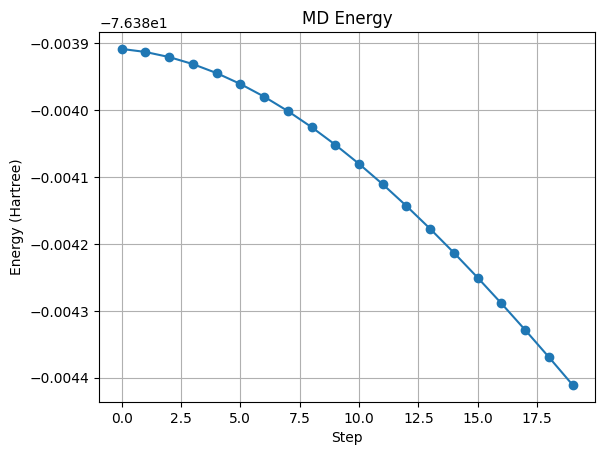

In [14]:
plt.plot(energies, "o-")
plt.xlabel("Step")
plt.ylabel("Energy (Hartree)")
plt.title("MD Energy")
plt.grid()
plt.show()